# PHASE 7 - GRU Time-Series Model

This notebook trains a small GRU model on CPU to predict bike demand from the previous 24 observations and their engineered features.

Leakage prevention: scalers are fit only on the training split, sequences preserve chronological order, and validation/test sequences use only preceding context. Training data is not shuffled.

In [1]:
from pathlib import Path
from time import perf_counter
import os
import pickle

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(42)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError:
    pass

def find_project_root():
    for candidate in [Path("."), Path("..")]:
        if (candidate / "data/processed/train.csv").exists():
            return candidate
    raise FileNotFoundError("Run PHASE 3 first to create data/processed/train.csv.")

project_root = find_project_root()
processed_dir = project_root / "data/processed"
metrics_dir = project_root / "results/metrics"
figures_dir = project_root / "results/figures"
models_dir = project_root / "models"
for directory in [metrics_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
def load_split(name):
    return pd.read_csv(processed_dir / f"{name}.csv", parse_dates=["timestamp", "dteday"])

train_df = load_split("train")
validation_df = load_split("validation")
test_df = load_split("test")

target_column = "cnt"
excluded_columns = {target_column, "instant", "dteday", "timestamp", "casual", "registered"}
feature_columns = [column for column in train_df.columns if column not in excluded_columns]
sequence_length = 24

assert train_df["timestamp"].max() < validation_df["timestamp"].min()
assert validation_df["timestamp"].max() < test_df["timestamp"].min()
print(f"Project root: {project_root.resolve()}")
print(f"Features: {len(feature_columns)}")
print(f"Rows train/validation/test: {len(train_df)}/{len(validation_df)}/{len(test_df)}")

Project root: D:\bike-demand-prediction
Features: 27
Rows train/validation/test: 12047/2582/2582


## Scale using training data only

In [ ]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])
X_validation_scaled = feature_scaler.transform(validation_df[feature_columns])
X_test_scaled = feature_scaler.transform(test_df[feature_columns])
y_train_scaled = target_scaler.fit_transform(train_df[[target_column]]).ravel()
y_validation_scaled = target_scaler.transform(validation_df[[target_column]]).ravel()
y_test_scaled = target_scaler.transform(test_df[[target_column]]).ravel()

print("Feature and target scalers fit on train only.")

Feature and target scalers fit on train only.


## Build chronological sequences

For validation and test, the preceding 24 scaled rows are supplied as context. These rows come from an earlier split and do not include future observations.

In [ ]:
def make_sequences(features, targets, sequence_length):
    sequence_features = []
    sequence_targets = []
    for index in range(sequence_length, len(features)):
        sequence_features.append(features[index - sequence_length:index])
        sequence_targets.append(targets[index])
    return np.asarray(sequence_features), np.asarray(sequence_targets)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, sequence_length)
validation_context_X = np.vstack([X_train_scaled[-sequence_length:], X_validation_scaled])
validation_context_y = np.concatenate([y_train_scaled[-sequence_length:], y_validation_scaled])
X_validation_seq, y_validation_seq = make_sequences(validation_context_X, validation_context_y, sequence_length)
test_context_X = np.vstack([X_validation_scaled[-sequence_length:], X_test_scaled])
test_context_y = np.concatenate([y_validation_scaled[-sequence_length:], y_test_scaled])
X_test_seq, y_test_seq = make_sequences(test_context_X, test_context_y, sequence_length)

assert len(X_train_seq) == len(train_df) - sequence_length
assert len(X_validation_seq) == len(validation_df)
assert len(X_test_seq) == len(test_df)
print(f"Sequence shapes: train={X_train_seq.shape}, validation={X_validation_seq.shape}, test={X_test_seq.shape}")

Sequence shapes: train=(12023, 24, 27), validation=(2582, 24, 27), test=(2582, 24, 27)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(sequence_length, len(feature_columns))),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1),
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

start_time = perf_counter()
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_validation_seq, y_validation_seq),
    epochs=30,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1,
)
training_time = perf_counter() - start_time
print(f"Training time: {training_time:.2f} seconds")
print(f"Epochs completed: {len(history.history['loss'])}")

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4585 - val_loss: 0.6098
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1975 - val_loss: 0.3855
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1285 - val_loss: 0.2865
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1026 - val_loss: 0.2472
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0873 - val_loss: 0.2196
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0782 - val_loss: 0.2046
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0721 - val_loss: 0.1954
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0679 - val_loss: 0.1886
Epoch 9/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0643 - val_loss: 0.1826
Epoch 10/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0617 - val_loss: 0.1786
Epoch 11/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0594 - val_loss: 0.1758
Epoch 12/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

In [ ]:
def calculate_metrics(y_true_scaled, predictions_scaled, split_name):
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).ravel()
    return {
        "model": "GRU",
        "split": split_name,
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "R2": r2_score(y_true, predictions),
        "Training Time": training_time,
    }

validation_predictions_scaled = model.predict(X_validation_seq, verbose=0).ravel()
test_predictions_scaled = model.predict(X_test_seq, verbose=0).ravel()
metrics = pd.DataFrame([
    calculate_metrics(y_validation_seq, validation_predictions_scaled, "validation"),
    calculate_metrics(y_test_seq, test_predictions_scaled, "test"),
])
display(metrics.round(4))
metrics.to_csv(metrics_dir / "gru_metrics.csv", index=False)

,model,split,MAE,RMSE,R2,Training Time
0,GRU,validation,46.5281,64.1135,0.9183,27.8381
1,GRU,test,48.2675,69.0899,0.8957,27.8381


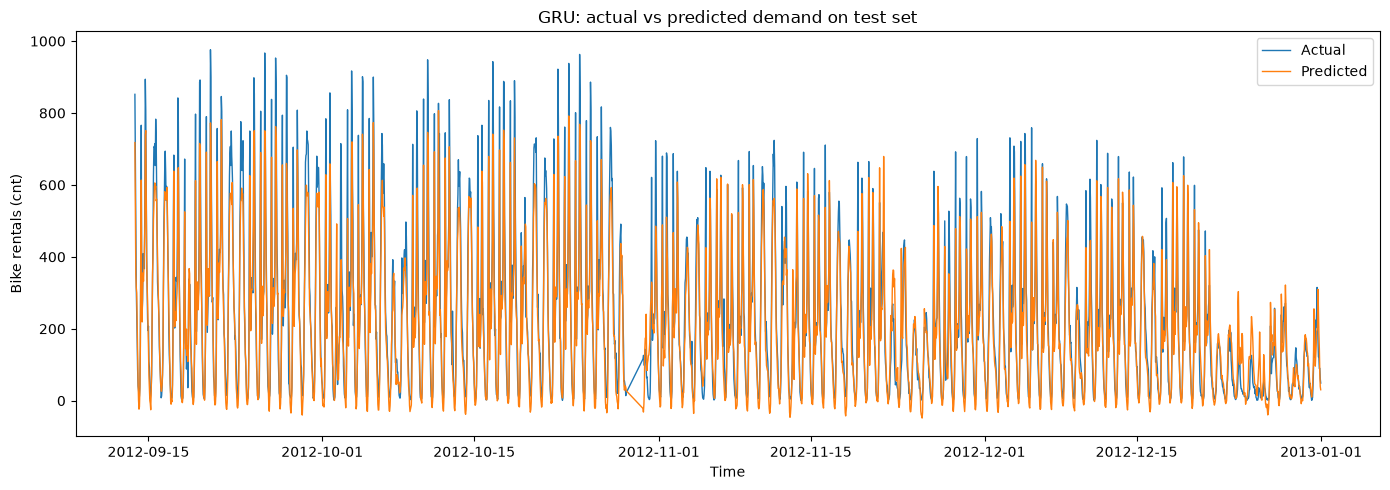

Saved model to: ..\models\gru.keras


In [ ]:
test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()
test_predictions = target_scaler.inverse_transform(test_predictions_scaled.reshape(-1, 1)).ravel()
comparison = pd.DataFrame({
    "timestamp": test_df["timestamp"].to_numpy(),
    "actual": test_actual,
    "predicted": test_predictions,
})

plt.figure(figsize=(14, 5))
plt.plot(comparison["timestamp"], comparison["actual"], label="Actual", linewidth=1)
plt.plot(comparison["timestamp"], comparison["predicted"], label="Predicted", linewidth=1)
plt.title("GRU: actual vs predicted demand on test set")
plt.xlabel("Time")
plt.ylabel("Bike rentals (cnt)")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "gru_actual_vs_predicted.png", dpi=150)
plt.show()

model_path = models_dir / "gru.keras"
model.save(model_path)
with (models_dir / "gru_preprocessing.pkl").open("wb") as scaler_file:
    pickle.dump({"feature_scaler": feature_scaler, "target_scaler": target_scaler, "feature_columns": feature_columns, "sequence_length": sequence_length}, scaler_file)
print(f"Saved model to: {model_path}")

## LSTM metrics

Train an LSTM model with the same chronological sequences and report validation/test metrics.

In [ ]:
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(sequence_length, len(feature_columns))),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1),
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
lstm_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

lstm_start_time = perf_counter()
lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_validation_seq, y_validation_seq),
    epochs=30,
    batch_size=64,
    shuffle=False,
    callbacks=[lstm_early_stopping],
    verbose=1,
)
lstm_training_time = perf_counter() - lstm_start_time

lstm_validation_predictions_scaled = lstm_model.predict(X_validation_seq, verbose=0).ravel()
lstm_test_predictions_scaled = lstm_model.predict(X_test_seq, verbose=0).ravel()

def calculate_lstm_metrics(y_true_scaled, predictions_scaled, split_name):
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).ravel()
    return {
        "model": "LSTM",
        "split": split_name,
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "R2": r2_score(y_true, predictions),
        "Training Time": lstm_training_time,
    }

lstm_metrics = pd.DataFrame([
    calculate_lstm_metrics(y_validation_seq, lstm_validation_predictions_scaled, "validation"),
    calculate_lstm_metrics(y_test_seq, lstm_test_predictions_scaled, "test"),
])
display(lstm_metrics.round(4))
lstm_metrics.to_csv(metrics_dir / "lstm_metrics.csv", index=False)
print(f"LSTM training time: {lstm_training_time:.2f} seconds")
print(f"Epochs completed: {len(lstm_history.history['loss'])}")